In [ ]:
# Step 0: Import TensorFlow (this automatically includes Keras, since Keras is part of TensorFlow 2)

import tensorflow as tf

# Print the TensorFlow version, just to know what we are using
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
# Step 1: Load the MNIST dataset from tf.keras.datasets
# This gives us:
#   x_train: 60,000 training images, shape (60000, 28, 28)
#   y_train: 60,000 labels (digits 0-9), shape (60000,)
#   x_test:  10,000 test images, shape (10000, 28, 28)
#   y_test:  10,000 test labels

mnist = tf.keras.datasets.mnist  # a small helper inside tf.keras for this dataset

(x_train, y_train), (x_test, y_test) = mnist.load_data()  # downloads the data storing them in (X_train, y_train, X_test, y_test)

# Let's inspect the shapes to understand what we got
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


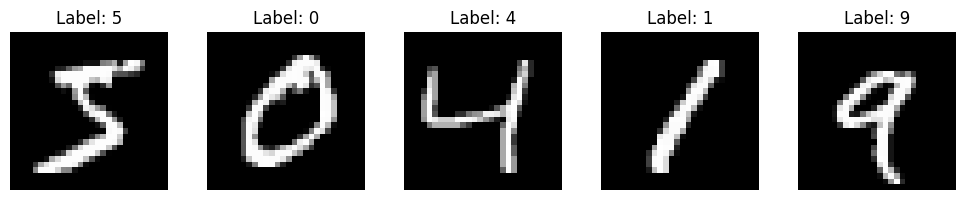

In [ ]:
import matplotlib.pyplot as plt

# Step 2: Visualize a few training images for better understanding
# We will use matplotlib to display the first 5 images and their labels.

# Set up a figure with 5 subplots in 1 row
plt.figure(figsize=(10, 2))  # width=10 inches, height=2 inches

# We will show images with indices 0,1,2,3,4 from x_train
for i in range(5):
    # Create the i-th subplot (1 row, 5 columns, index i+1)
    plt.subplot(1, 5, i + 1)

    # Show the 2D image (28x28). We use cmap='gray' to display it as a grayscale image.
    plt.imshow(x_train[i], cmap='gray')

    # Set the title as the corresponding label (digit 0-9)
    plt.title(f"Label: {y_train[i]}")

    # Turn off axis ticks and numbers for cleaner display
    plt.axis('off')

# Make layout tight so titles and images don't overlap
plt.tight_layout()
plt.show()

In [ ]:
# Step 3: Normalize the images
# We convert from integers [0, 255] to floating-point numbers [0.0, 1.0]
# by dividing by 255.0 (a float).

x_train = x_train / 255.0
x_test  = x_test  / 255.0

# check the new data type and a few values
print("x_train dtype after normalization:", x_train.dtype)
print("Min/Max of x_train:", x_train.min(), x_train.max())

x_train dtype after normalization: float64
Min/Max of x_train: 0.0 1.0


**What is a neuron and a layer?**

Think about this line in the model:

`layers.Dense(128, activation='relu')`

Conceptually:

**Input to this layer (for one image):** a vector of length 784 (flattened 28×28).

**Layer has 128 neurons, each neuron does:**

1.   Take all 784 inputs
2.   Multiply each input by a weight
3.   Add a bias
4.   Apply relu activation (max(0, x)).
5.   The next layer uses these 128 values as its inputs.

So:

A layer is just a group of neurons with shared input.

Your network is: Input → Hidden Dense (128) → Output Dense (10).



In [ ]:
from tensorflow.keras import layers, models

# Step 4: Build the model using the Keras Sequential API
# A Sequential model is just a stack of layers, where each layer has one input and one output.

model = models.Sequential([  # we pass a list of layers
    # 1) Flatten layer: transforms each 28x28 image into a 1D vector of length 784
    #    Input shape is (28, 28) because each MNIST image is 28x28.
    layers.Flatten(input_shape=(28, 28)),

    # 2) Dense (fully-connected) layer with 128 units and ReLU activation.
    #    This is our "hidden layer" that learns useful features.
    layers.Dense(128, activation='relu'),

    # 3) Output Dense layer with 10 units (one for each digit class 0-9).
    #    We do NOT apply softmax here because we'll use a loss function
    #    that expects raw logits (logits = unnormalized scores).
    layers.Dense(10)
])

# Let's see a summary of the model to understand layers and parameters
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

# **Another way (with Explicit Input layer) to build model with keras**

In [ ]:
from tensorflow.keras import Input
from tensorflow.keras import layers, models

# Step 4: Build the model using the Keras Sequential API
# A Sequential model is just a stack of layers, where each layer has one input and one output.

model = models.Sequential([
    # Explicit Input layer defines the shape of each sample: 28x28 grayscale image
    Input(shape=(28, 28)),          # no batch size here, just the shape of ONE image
    layers.Flatten(),               # now Flatten just flattens whatever comes in
    layers.Dense(128, activation='relu'),
    layers.Dense(10)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

**What are logits vs probabilities?**

In the last layer:

`layers.Dense(10)  # no activation`

For each image:

Outputs a vector of 10 real numbers: **logits**.

They can be any values (e.g., `[-3.1, 2.5, 0.2, ...]`), not between 0 and 1, don’t sum to anything special.

Then:

In training, the loss function applies softmax internally (because from `logits=True`) to turn logits into probabilities.

In prediction step, we explicitly add a Softmax layer:

`probability_model = tf.keras.Sequential([
    model,
    layers.Softmax()
])`

This converts logits into probabilities that sum to 1 for each image.
​

So:

**Logits:** raw scores from the model.

**Softmax output:** probabilities used to compare with the true label.



In [ ]:
# Step 5: Compile the model
# - optimizer: how we update weights (Adam is a very common choice)
# - loss: what we try to minimize (here, multi-class classification loss)
# - metrics: extra values we want to monitor (accuracy, etc.)

#
# IMPORTANT: from_logits=True
# --------------------------------
# Our last layer is: layers.Dense(10)  WITHOUT an activation.
# That means it outputs "logits" = raw scores (any real numbers, not probabilities).
#
# If from_logits=True:
#   - the loss function knows that the inputs are raw logits
#   - it will internally apply a numerically stable softmax + log
#   - this is the CORRECT choice for our current model structure.
#
# If we did NOT set from_logits=True here:
#   - TensorFlow would assume the model outputs PROBABILITIES (already softmaxed)
#   - but our model actually outputs logits
#   - the loss computation would be wrong,
#     and training would be unstable or give poor accuracy.
#
# Alternative design:
#   - If we change the last layer to: Dense(10, activation='softmax')
#   - then we should use: SparseCategoricalCrossentropy(from_logits=False) or just default
#   - because then the model already returns probabilities.

# We use SparseCategoricalCrossentropy because our labels are integers 0–9,
# not one-hot vectors like [0,0,0,0,1,0,0,0,0,0].
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer='adam',
    loss=loss_fn,
    metrics=['accuracy']  # we want to see accuracy during training and evaluation
)

**Epochs, batches, and steps**

When we called:


`history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)`

Behind the scenes:

**epochs=5** → loop over the training set 5 times.

Keras chooses a default batch size (usually 32) if you don’t specify.
​

**One step/iteration = one batch update**.
​

**Example intuition:**

Suppose 54,000 training samples (because 6,000 are held out as validation).

With batch size 32, steps per epoch ≈ 54000 / 32 ≈ 1688 steps.
​

Each epoch, Keras does ~1688 weight updates.

**So epochs controls how many times the model sees the whole dataset; batch size controls how many samples per update.**

In [ ]:
# Step 6: Train the model
# - epochs: how many times we pass over the entire training set
# - batch_size: how many samples per gradient update (we'll use the default for now)
# By default, Keras will show us loss and accuracy per epoch.

history = model.fit(
    x_train,           # training images
    y_train,           # training labels
    epochs=5,          # number of passes over the training data
    validation_split=0.1  # keep 10% of training data as validation to monitor overfitting
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8682 - loss: 0.4533 - val_accuracy: 0.9642 - val_loss: 0.1216
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9610 - loss: 0.1314 - val_accuracy: 0.9730 - val_loss: 0.0924
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9756 - loss: 0.0846 - val_accuracy: 0.9763 - val_loss: 0.0829
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9814 - loss: 0.0628 - val_accuracy: 0.9792 - val_loss: 0.0707
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9851 - loss: 0.0495 - val_accuracy: 0.9773 - val_loss: 0.0743


**Accuracy: how is it computed?**

During training/evaluation:

For each example, model predicts a class (via logits → softmax → argmax).

Accuracy = (number of correct predictions) / (total samples).

When we see:

text
loss: 0.03 - accuracy: 0.99 - val_loss: ... - val_accuracy: ...

**accuracy:** training accuracy for that epoch.

**val_accuracy:** validation accuracy (on held‑out data).
​

**High training accuracy + much lower validation accuracy → overfitting hint**

In [ ]:
# Step 7: Evaluate the model on the test set
#
# verbose parameter controls how much text Keras prints:
#   verbose=0  -> no output (silent, just returns numbers)
#   verbose=1  -> progress bar + metrics for evaluation
#   verbose=2  -> one line per epoch / per call, no progress bar (cleaner logs in notebooks)
#
# We use verbose=2 here so the output is short and readable in Colab.
# If we removed verbose or used verbose=1, you'd see a progress bar instead.
# If we used verbose=0, it would print nothing; you'd only see the variables we print ourselves.
#
# model.evaluate returns the loss and any metrics we asked for in compile.
# loss is always tracked (as we defined loss function to calculate loss (loss=))
# and during compile we asked for accuracy only (metrics=['accuracy'])

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.9759 - loss: 0.0831
Test loss: 0.08313688635826111
Test accuracy: 0.9758999943733215


In [ ]:
# Step 8: Make predictions on some test images

# 1) Create a new model that adds a softmax layer on top of our trained model
probability_model = tf.keras.Sequential([
    model,
    layers.Softmax()
    # Softmax takes the raw logits (any real numbers) and converts them into
    # probabilities between 0 and 1 for each class, such that all probabilities
    # for a given example sum to 1.

])

# 2) Get predictions for the first 5 test images
predictions = probability_model(x_test[:5])  # shape (5, 10) [5 images each gives probabilites of chance digit 0-9, so total 10]

print("Predictions shape:", predictions.shape)
print("Probabilities for first sample:", predictions[0])

# 3) Get the predicted class index (0-9) with argmax
# axis = 1 means: for each row, look across columns (classes) and pick the index of the biggest probability.
predicted_labels = tf.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels.numpy())
print("True labels:", y_test[:5])

Predictions shape: (5, 10)
Probabilities for first sample: tf.Tensor(
[2.8324911e-07 4.4869719e-08 5.0794956e-06 3.7087488e-05 1.9415110e-12
 4.0085438e-06 8.3101876e-12 9.9994802e-01 5.1368961e-08 5.3775411e-06], shape=(10,), dtype=float32)
Predicted labels: [7 2 1 0 4]
True labels: [7 2 1 0 4]


In [ ]:
# checking one test image
sample = x_test[0:1]  # shape (1, 28, 28)

logits = model(sample)  # shape (1, 10)
probs = tf.nn.softmax(logits, axis=1)

print("Logits:", logits.numpy())
print("Softmax probabilities:", probs.numpy())
print("Sum of probs:", probs.numpy().sum())
print("Predicted class:", tf.argmax(probs, axis=1).numpy())
print("True label:", y_test[0])

Logits: [[ -6.9438777  -7.449962    2.3489165   2.9269588 -12.164281   -3.6969
  -16.840427   12.647109   -2.333726   -1.796639 ]]
Softmax probabilities: [[3.1024274e-09 1.8703030e-09 3.3690732e-05 6.0055299e-05 1.6769074e-11
  7.9771134e-08 1.5620109e-13 9.9990523e-01 3.1179192e-07 5.3348049e-07]]
Sum of probs: 0.9999999
Predicted class: [7]
True label: 7


In [ ]:
print("History keys:", history.history.keys())
print("First epoch - loss:", history.history['loss'][0])
print("First epoch - accuracy:", history.history['accuracy'][0])
print("Last epoch - loss:", history.history['loss'][-1])
print("Last epoch - accuracy:", history.history['accuracy'][-1])

History keys: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
First epoch - loss: 0.2744964063167572
First epoch - accuracy: 0.9211666584014893
Last epoch - loss: 0.04801788553595543
Last epoch - accuracy: 0.9852592349052429
